# 02 · Technology Hype Cycles

HN is a real-time seismograph of the tech industry. By tracking how often each technology appears in story titles, we can draw its full life cycle: birth, hype peak, and decline.

**Headline chart:** A heatmap of 30+ technologies × 18 years — the graveyard and the nursery of tech in a single image.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.loader import db
from src.nlp import TECH_KEYWORDS, keyword_hits
from src.viz import set_style, hype_heatmap, time_series, save

set_style()
con = db()

## Load stories with year

In [2]:
stories = con.execute("""
    SELECT title, YEAR(posted_at) AS year, score
    FROM stories
    WHERE year BETWEEN 2007 AND 2024
      AND score >= 1
""").df()

print(f'{len(stories):,} stories loaded')
stories.head()

5,052,581 stories loaded


,title,year,score
0,From Oxford to Silicon Valley,2007,25
1,From Oxford to Silicon Valley,2007,6
2,Y Europe can seed growth of its new stars,2007,13
3,Adobe gives new flash tools only to Photobucket,2007,12
4,New Revenue Stream For Bloggers: TextMark SMS ...,2007,3


## Tag each story with matching keywords

In [3]:
for name, patterns in TECH_KEYWORDS.items():
    col = f'kw_{name}'
    stories[col] = stories['title'].apply(lambda t: keyword_hits(str(t), patterns))

print('Keyword columns added:', [c for c in stories.columns if c.startswith('kw_')][:5], '...')

Keyword columns added: ['kw_Python', 'kw_Ruby', 'kw_PHP', 'kw_Go', 'kw_Rust'] ...


## Build normalized frequency matrix

In [4]:
kw_cols = [f'kw_{k}' for k in TECH_KEYWORDS]
stories_per_year = stories.groupby('year').size().rename('total')

# Sum hits per keyword per year, normalize by total stories that year
freq = stories.groupby('year')[kw_cols].sum()
freq_norm = freq.div(stories_per_year, axis=0) * 10_000  # per 10k stories

# Rename columns to clean labels
freq_norm.columns = list(TECH_KEYWORDS.keys())
freq_norm = freq_norm.T  # technologies as rows, years as columns

# Keep only techs with at least one year above threshold
freq_norm = freq_norm[freq_norm.max(axis=1) > 1]

# Sort by year of peak mention
freq_norm['peak_year'] = freq_norm.idxmax(axis=1)
freq_norm = freq_norm.sort_values('peak_year').drop(columns='peak_year')

print(freq_norm.shape)
freq_norm

(26, 18)


year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Ruby,140.174439,169.590560,104.489164,84.291787,67.190436,79.486504,85.701296,71.264787,54.080175,43.163844,32.694324,32.783379,25.428742,22.106261,26.438041,22.568005,32.802899,33.403680
Twitter/X,64.969740,134.674856,243.718050,129.091000,112.348420,107.546236,97.554639,76.008897,64.206742,61.387354,42.749980,45.446487,37.512301,55.497196,57.759025,154.398588,98.660785,20.264003
PHP,22.249911,38.050991,44.189646,37.705074,39.077711,44.837716,40.366317,32.521220,29.394745,22.132481,20.272632,19.022802,14.214302,13.600103,12.571558,8.726295,8.287380,9.577514
Heroku,0.444998,3.562827,4.499964,7.652733,9.496157,13.917370,15.425584,8.938179,6.802344,4.817393,5.027828,3.123567,2.859682,3.631569,3.075446,6.218739,2.174256,2.554004
Bitcoin,0.000000,0.000000,0.179999,0.782031,20.358668,14.303071,125.255740,131.838136,70.178031,46.219447,109.402307,90.667852,47.773513,40.897802,85.276170,42.628454,20.513628,26.917855
Go,52.509790,49.167011,48.599611,43.179292,43.928266,50.783937,70.373137,77.762155,86.583684,107.138826,92.409862,93.284895,85.594211,86.718939,77.398713,80.108059,72.853317,77.090586
Scala,18.244927,23.229631,20.699834,19.439060,21.349274,21.117118,23.966486,23.858062,20.068454,25.133029,21.670744,22.821734,19.092584,15.452447,14.433012,14.309787,12.919490,15.088785
Docker,0.000000,1.425131,2.609979,2.290234,1.878736,1.799937,14.353912,46.375397,70.147251,70.196302,62.000914,45.474627,43.820423,43.237605,37.471876,31.494905,28.548921,27.993225
Microservices,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.056558,14.189505,18.691486,17.691501,15.871095,12.391956,12.722677,8.821673,6.753684,6.900898,4.603928
DevOps,0.000000,0.000000,0.000000,1.619922,2.220325,3.696299,7.176956,12.719716,15.513038,20.343164,18.713199,15.786674,12.868570,14.306919,10.979880,6.920855,7.247519,4.032637


## The headline heatmap

In [5]:
fig = hype_heatmap(
    freq_norm,
    title='Technology Hype Cycles on Hacker News (2007–2024)\nMentions per 10,000 stories'
)
save(fig, '../data/fig_hype_heatmap.png')
plt.show()
print('Key patterns to look for:')
print('  - Bitcoin/Blockchain peak: 2017–2018')
print('  - ChatGPT/LLM spike: 2023 onward')
print('  - Heroku flatline after 2022 (Salesforce killed free tier)')
print('  - Ruby decline: post-2014')

Key patterns to look for:
  - Bitcoin/Blockchain peak: 2017–2018
  - ChatGPT/LLM spike: 2023 onward
  - Heroku flatline after 2022 (Salesforce killed free tier)
  - Ruby decline: post-2014


## AI discourse timeline — the ChatGPT inflection

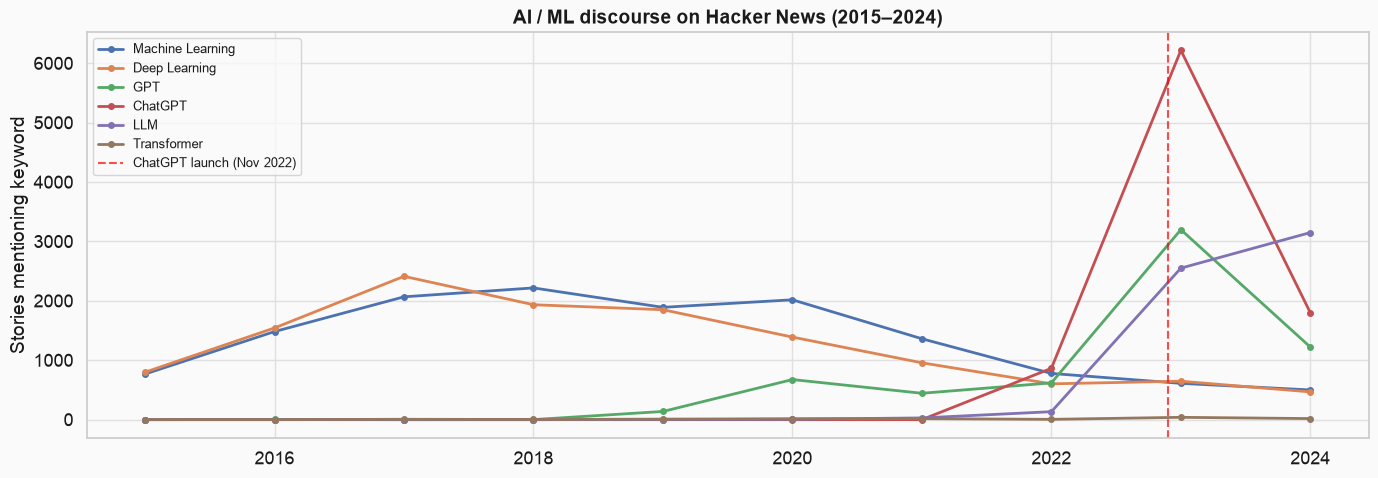

In [6]:
ai_cols = ['kw_Machine Learning', 'kw_Deep Learning', 'kw_GPT', 'kw_ChatGPT', 'kw_LLM']
ai_monthly = con.execute("""
    SELECT
        DATE_TRUNC('month', posted_at) AS month,
        COUNT(*) AS total
    FROM stories
    WHERE YEAR(posted_at) >= 2015
    GROUP BY 1
    ORDER BY 1
""").df()

# Add monthly AI keyword counts
ai_stories = stories[stories['year'] >= 2015].copy()
# (simplified: use the tagged dataframe we already have)

fig, ax = plt.subplots(figsize=(14, 5))
for kw in ['Machine Learning', 'Deep Learning', 'GPT', 'ChatGPT', 'LLM', 'Transformer']:
    col = f'kw_{kw}'
    if col not in stories.columns:
        continue
    monthly = stories[stories['year'] >= 2015].groupby('year')[col].sum()
    ax.plot(monthly.index, monthly.values, linewidth=2, label=kw, marker='o', markersize=4)

ax.axvline(x=2022.9, color='red', linestyle='--', alpha=0.7, label='ChatGPT launch (Nov 2022)')
ax.set_title('AI / ML discourse on Hacker News (2015–2024)', fontsize=14, fontweight='bold')
ax.set_ylabel('Stories mentioning keyword')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../data/fig_ai_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

## "X is dead" — technology obituaries

/var/folders/4j/zr7sj26s4y133367d5fl89540000gn/T/ipykernel_40412/906153741.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  obituaries = stories[stories['title'].str.contains(dead_pattern, case=False, na=False, regex=True)]


8,645 obituary posts found


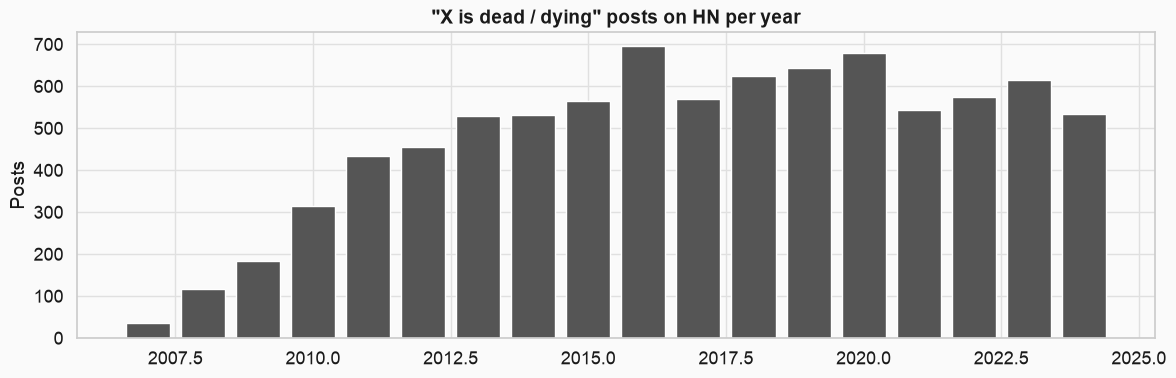


Top obituary titles:
                                                                         title  year  score
                                                        Google Search Is Dying  2022   3636
                                             The man who killed Google Search?  2024   1884
                                                           Sunsetting Python 2  2019   1616
                                             "DigitalOcean Killed Our Company"  2019   1343
                                                               Sunsetting Atom  2022   1320
                                              Apollo is dead. Long live Apollo  2023   1036
                                                       Osama bin Laden Is Dead  2011    924
                                                              Big data is dead  2023    879
Atta Elayyan, Developer of MetroTube and LazyWorm Apps, Killed in Christchurch  2019    871
                Jeff Bezos killed Washington Post endorsem

In [7]:
import re

dead_pattern = r'\b(is dead|is dying|is over|killed|deprecated|sunsetting)\b'
obituaries = stories[stories['title'].str.contains(dead_pattern, case=False, na=False, regex=True)]

print(f'{len(obituaries):,} obituary posts found')

obit_by_year = obituaries.groupby('year').size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(obit_by_year.index, obit_by_year.values, color='#555', edgecolor='white')
ax.set_title('"X is dead / dying" posts on HN per year', fontsize=14, fontweight='bold')
ax.set_ylabel('Posts')
plt.tight_layout()
plt.savefig('../data/fig_obituaries.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop obituary titles:')
print(obituaries.nlargest(20, 'score')[['title', 'year', 'score']].to_string(index=False))